# Azobenzene S0/S1 energy surfaces

Plot the raw reference ground-state (S0) and first-excited-state (S1) energies over the C–N=N–C dihedral and N=N bond-length coordinates.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.io import read

# Support launching Jupyter from either notebooks/ or the repository root.
XYZ_NAME = Path("data/azoflip_data/XYZ/cis_trans_azobenzenes.xyz")
XYZ_PATH = next((candidate for candidate in (Path.cwd() / XYZ_NAME, Path.cwd().parent / XYZ_NAME) if candidate.exists()), None)
if XYZ_PATH is None:
    raise FileNotFoundError(f"Could not find {XYZ_NAME} from {Path.cwd()}")
DIHEDRAL_ATOMS = (3, 4, 5, 6)  # C–N=N–C; zero-based ASE atom indices
NN_ATOMS = (4, 5)

frames = read(XYZ_PATH, index=":")
dihedral_deg = np.asarray([atoms.get_dihedral(*DIHEDRAL_ATOMS) for atoms in frames])
nn_bond_angstrom = np.asarray([atoms.get_distance(*NN_ATOMS) for atoms in frames])
energies_hartree = np.vstack([np.asarray(atoms.info["REF_energy"], dtype=float).ravel()[:2] for atoms in frames])

if energies_hartree.shape[1] != 2:
    raise ValueError(f"Expected S0 and S1 energies, got shape {energies_hartree.shape}.")

print(f"Loaded {len(frames)} geometries")
print(f"Dihedral range: {dihedral_deg.min():.1f}–{dihedral_deg.max():.1f}°")
print(f"N=N range: {nn_bond_angstrom.min():.3f}–{nn_bond_angstrom.max():.3f} Å")

Loaded 17260 geometries
Dihedral range: 0.0–360.0°
N=N range: 1.130–4.634 Å


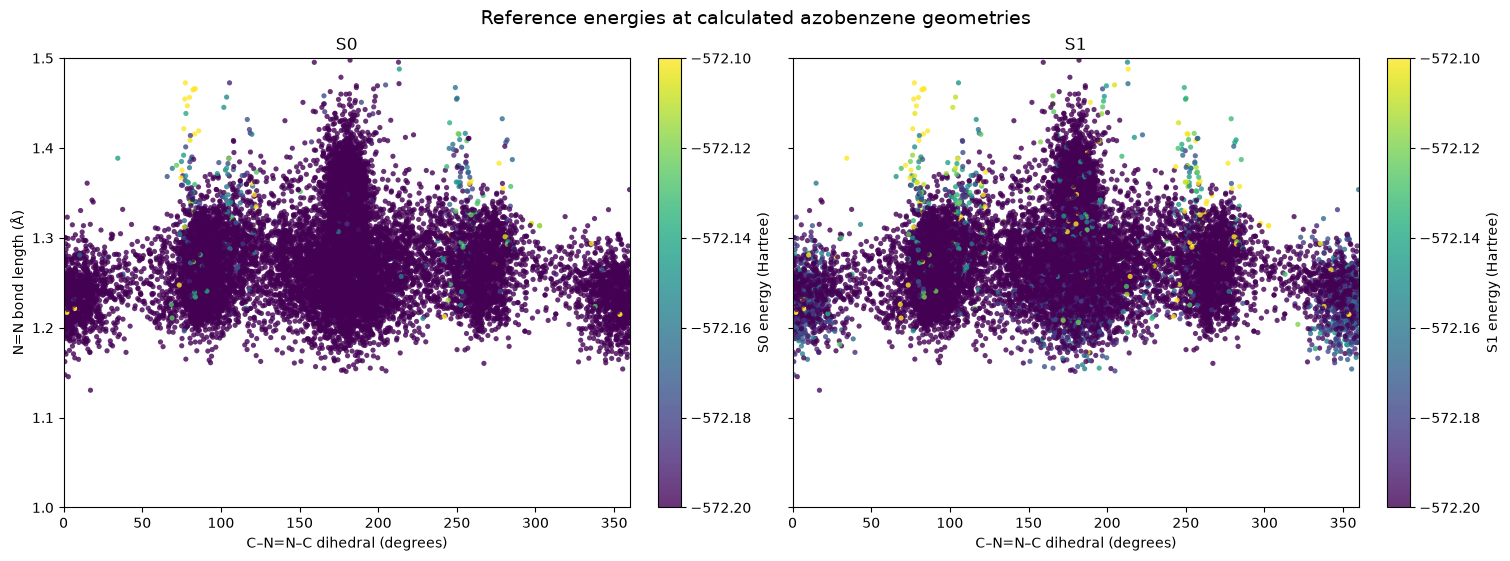

In [19]:
# Plot only calculated geometries: no interpolation is performed between points.

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True, constrained_layout=True)
for state, ax in enumerate(axes):
    surface = ax.scatter(
        dihedral_deg, nn_bond_angstrom, c=energies_hartree[:, state],
        cmap="viridis", s=14, alpha=0.8, linewidths=0,
        vmax=-572.1, vmin=-572.2
    )
    ax.set_title(f"S{state}")
    ax.set_xlabel("C–N=N–C dihedral (degrees)")
    ax.set_xlim(0, 360)
    ax.set_ylim(1.0,1.5)
    fig.colorbar(surface, ax=ax, label=f"S{state} energy (Hartree)")

axes[0].set_ylabel("N=N bond length (Å)")
fig.suptitle("Reference energies at calculated azobenzene geometries", fontsize=14)
plt.show()

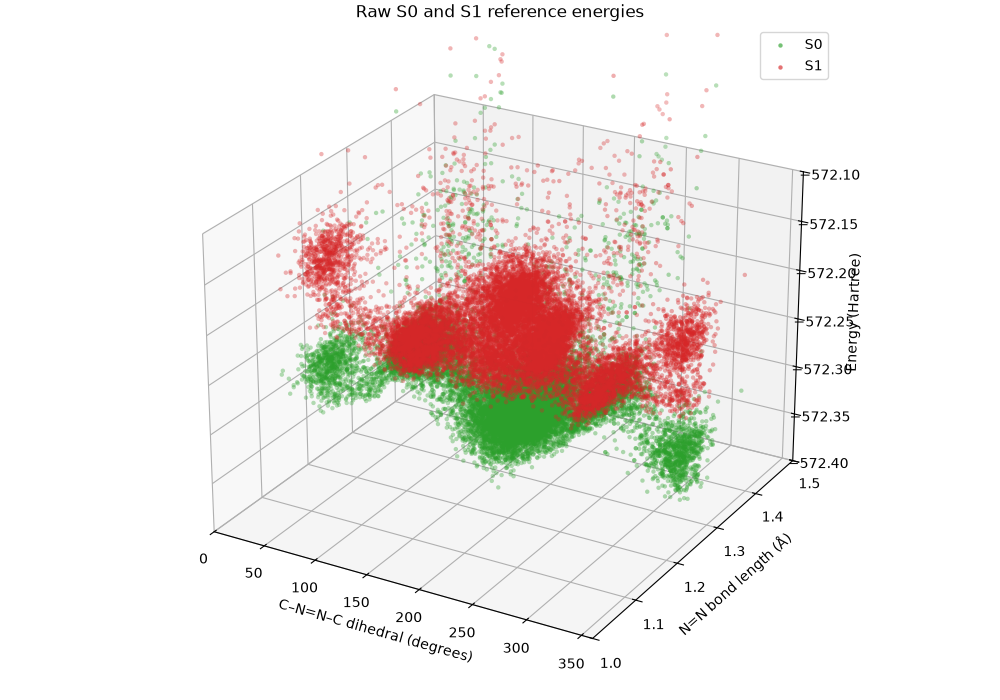

In [22]:
# 3D view of the calculated points, using the raw reference energies.
%matplotlib widget
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_hartree[:, 0],
    color="tab:green", s=10, alpha=0.65, linewidths=0, label="S0",
)
ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_hartree[:, 1],
    color="tab:red", s=10, alpha=0.65, linewidths=0, label="S1",
)

ax.set_xlabel("C–N=N–C dihedral (degrees)")
ax.set_ylabel("N=N bond length (Å)")
ax.set_zlabel("Energy (Hartree)")
ax.set_xlim(0, 360)
ax.set_ylim(1.0, 1.5)
ax.set_zlim(-572.4, -572.1)
ax.view_init(elev=25, azim=-60)
ax.legend()
ax.set_title("Raw S0 and S1 reference energies")
plt.show()